# Product Line Profitability & Margin Performance Analysis
## Nassau Candy Distributor

### Objective
The objective of this analysis is to identify profitable and unprofitable
products and divisions by analyzing sales, cost, and gross profit data.
This will help the organization take data-driven decisions on pricing,
cost optimization, and product portfolio rationalization.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("Nassau_Candy_Distributor.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


## Dataset Overview

The dataset contains order-level sales, cost, and profit information
across multiple product divisions and regions.
Key financial fields include Sales, Units, Cost, and Gross Profit.

In [6]:
df = df[df['Sales'] > 0]
df = df[df['Units'] > 0]
df = df.dropna(subset=['Gross Profit'])

In [7]:
df['Division'] = df['Division'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()

## Data Cleaning & Validation

Invalid records such as zero sales, zero units, and missing profit values
were removed to ensure accurate margin and profitability calculations.

In [9]:
df['Gross_Margin'] = df['Gross Profit'] / df['Sales']
df['Profit_per_Unit'] = df['Gross Profit'] / df['Units']

## Profitability Metrics

Gross Margin and Profit per Unit were calculated to evaluate
pricing efficiency and cost effectiveness at the product level.

In [11]:
product_summary = df.groupby('Product Name')[[
    'Sales', 'Units', 'Cost', 'Gross Profit'
]].sum()

product_summary['Gross_Margin'] = (
    product_summary['Gross Profit'] / product_summary['Sales']
)

product_summary['Profit_per_Unit'] = (
    product_summary['Gross Profit'] / product_summary['Units']
)

product_summary.head()

,Sales,Units,Cost,Gross Profit,Gross_Margin,Profit_per_Unit
Product Name,,,,,,
Everlasting Gobstopper,130.00,13,26.0,104.00,0.800000,8.00
Fizzy Lifting Drinks,78.75,21,31.5,47.25,0.600000,2.25
Fun Dip,12.00,8,7.2,4.80,0.400000,0.60
Hair Toffee,76.50,17,17.0,59.50,0.777778,3.50
Kazookles,1205.75,371,1113.0,92.75,0.076923,0.25


In [12]:
print("--- Top 5 Products by Gross Profit ---")
display(product_summary.sort_values(by='Gross Profit', ascending=False)[['Sales', 'Gross Profit', 'Gross_Margin']].head(5))

print("\n--- Top 5 Products by Gross Margin (%) ---")
display(product_summary.sort_values(by='Gross_Margin', ascending=False)[['Sales', 'Gross Profit', 'Gross_Margin']].head(5))

--- Top 5 Products by Gross Profit ---


,Sales,Gross Profit,Gross_Margin
Product Name,,,
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,0.694444
Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,0.653333
Wonka Bar - Milk Chocolate,26867.75,17443.37,0.649231
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,0.713467
Wonka Bar - Fudge Mallows,24890.40,16593.60,0.666667



--- Top 5 Products by Gross Margin (%) ---


,Sales,Gross Profit,Gross_Margin
Product Name,,,
Everlasting Gobstopper,130.00,104.00,0.800000
Hair Toffee,76.50,59.50,0.777778
Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,0.713467
Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,0.694444
Wonka Bar - Fudge Mallows,24890.40,16593.60,0.666667


## Product-Level Profitability Analysis

Products were analyzed based on total sales, gross profit,
gross margin, and profit per unit to identify performance patterns.

In [14]:
sales_threshold = product_summary['Sales'].quantile(0.70)
margin_threshold = product_summary['Gross_Margin'].mean()

product_summary['Margin_Risk'] = (
    (product_summary['Sales'] >= sales_threshold) &
    (product_summary['Gross_Margin'] < margin_threshold)
)

product_summary.head()

,Sales,Units,Cost,Gross Profit,Gross_Margin,Profit_per_Unit,Margin_Risk
Product Name,,,,,,,
Everlasting Gobstopper,130.00,13,26.0,104.00,0.800000,8.00,False
Fizzy Lifting Drinks,78.75,21,31.5,47.25,0.600000,2.25,False
Fun Dip,12.00,8,7.2,4.80,0.400000,0.60,False
Hair Toffee,76.50,17,17.0,59.50,0.777778,3.50,False
Kazookles,1205.75,371,1113.0,92.75,0.076923,0.25,False


In [15]:
def categorize_product(row):
    if row['Gross Profit'] >= product_summary['Gross Profit'].median() and row['Gross_Margin'] >= margin_threshold:
        return 'High-Profit / High-Margin'
    elif row['Sales'] >= sales_threshold and row['Gross_Margin'] < margin_threshold:
        return 'High-Sales / Low-Margin (Risk)'
    else:
        return 'Low-Sales / Low-Profit'

product_summary['Performance_Category'] = product_summary.apply(categorize_product, axis=1)
print("Product Counts by Segment Category:")
print(product_summary['Performance_Category'].value_counts())

Product Counts by Segment Category:
Performance_Category
Low-Sales / Low-Profit       9
High-Profit / High-Margin    6
Name: count, dtype: int64


Products with high sales but below-average margins were flagged as margin risk,
indicating potential pricing or cost inefficiencies.

In [17]:
division_summary = df.groupby('Division')[[
    'Sales', 'Gross Profit'
]].sum()

division_summary['Gross_Margin'] = (
    division_summary['Gross Profit'] / division_summary['Sales']
)

division_summary

,Sales,Gross Profit,Gross_Margin
Division,,,
Chocolate,131692.90,88824.62,0.674483
Other,9663.25,4333.45,0.448446
Sugar,427.48,284.73,0.666066


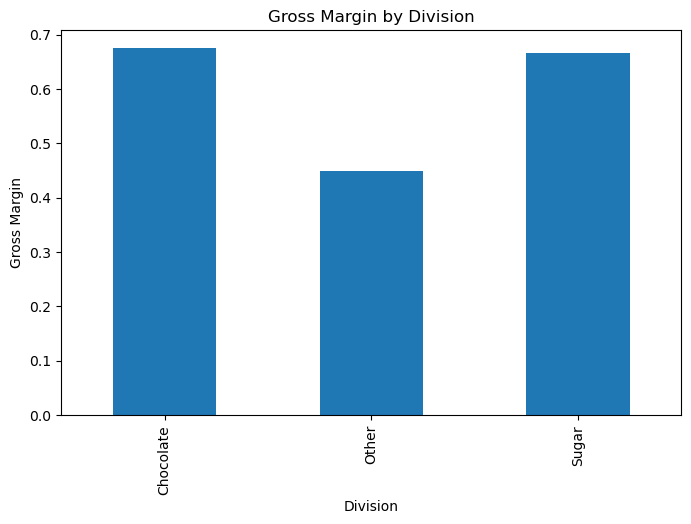

In [18]:
division_summary['Gross_Margin'].plot(
    kind='bar',
    figsize=(8,5),
    title='Gross Margin by Division'
)
plt.ylabel('Gross Margin')
plt.show()

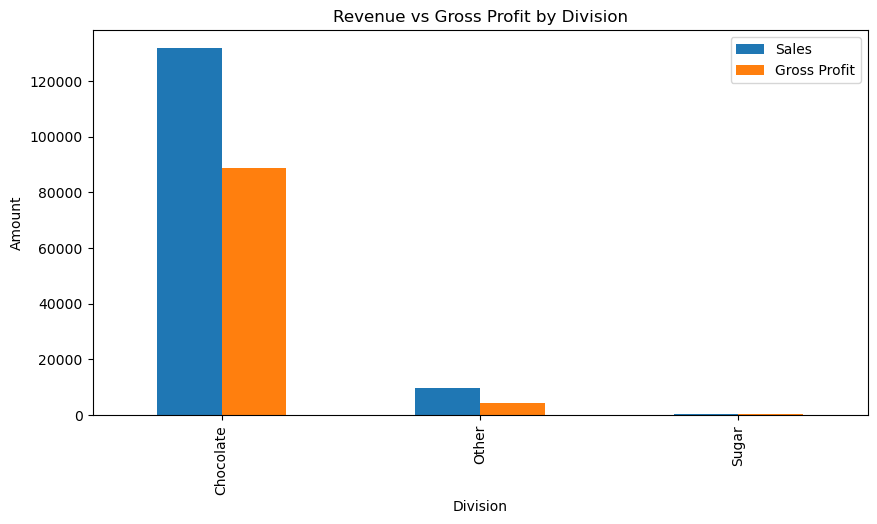

In [19]:
division_summary[['Sales','Gross Profit']].plot(
    kind='bar',
    figsize=(10,5)
)
plt.title('Revenue vs Gross Profit by Division')
plt.ylabel('Amount')
plt.show()

In [20]:
division_summary['Sales_Share_%'] = (division_summary['Sales'] / division_summary['Sales'].sum()) * 100
division_summary['Profit_Share_%'] = (division_summary['Gross Profit'] / division_summary['Gross Profit'].sum()) * 100

print("--- Division Performance Share Breakdown ---")
display(division_summary[['Sales_Share_%', 'Profit_Share_%', 'Gross_Margin']])

--- Division Performance Share Breakdown ---


,Sales_Share_%,Profit_Share_%,Gross_Margin
Division,,,
Chocolate,92.883008,95.057747,0.674483
Other,6.815491,4.637543,0.448446
Sugar,0.301502,0.304710,0.666066


In [21]:
product_sorted_profit = product_summary.sort_values(by='Gross Profit', ascending=False)
product_sorted_profit['Cum_Profit_Pct'] = product_sorted_profit['Gross Profit'].cumsum() / product_sorted_profit['Gross Profit'].sum()
top_80_profit = product_sorted_profit[product_sorted_profit['Cum_Profit_Pct'] <= 0.80]
pct_products_profit = (len(top_80_profit) / len(product_summary)) * 100

product_sorted_sales = product_summary.sort_values(by='Sales', ascending=False)
product_sorted_sales['Cum_Sales_Pct'] = product_sorted_sales['Sales'].cumsum() / product_sorted_sales['Sales'].sum()
top_80_sales = product_sorted_sales[product_sorted_sales['Cum_Sales_Pct'] <= 0.80]
pct_products_sales = (len(top_80_sales) / len(product_summary)) * 100

print("--- Pareto Concentration Diagnostics ---")
print(f"-> {pct_products_profit:.2f}% of unique products generate 80% of total Gross Profit.")
print(f"-> {pct_products_sales:.2f}% of unique products generate 80% of total Revenue (Sales).")

--- Pareto Concentration Diagnostics ---
-> 26.67% of unique products generate 80% of total Gross Profit.
-> 26.67% of unique products generate 80% of total Revenue (Sales).


Pareto analysis shows that a small subset of products contributes
to the majority of total gross profit, highlighting dependency risk.

In [23]:
product_summary['Revenue_Contribution_%'] = (
    product_summary['Sales'] / product_summary['Sales'].sum()
) * 100

product_summary['Profit_Contribution_%'] = (
    product_summary['Gross Profit'] / product_summary['Gross Profit'].sum()
) * 100

product_summary.head()

,Sales,Units,Cost,Gross Profit,Gross_Margin,Profit_per_Unit,Margin_Risk,Performance_Category,Revenue_Contribution_%,Profit_Contribution_%
Product Name,,,,,,,,,,
Everlasting Gobstopper,130.00,13,26.0,104.00,0.800000,8.00,False,High-Profit / High-Margin,0.091689,0.111298
Fizzy Lifting Drinks,78.75,21,31.5,47.25,0.600000,2.25,False,Low-Sales / Low-Profit,0.055542,0.050566
Fun Dip,12.00,8,7.2,4.80,0.400000,0.60,False,Low-Sales / Low-Profit,0.008464,0.005137
Hair Toffee,76.50,17,17.0,59.50,0.777778,3.50,False,Low-Sales / Low-Profit,0.053955,0.063675
Kazookles,1205.75,371,1113.0,92.75,0.076923,0.25,False,Low-Sales / Low-Profit,0.850416,0.099259


### Revenue & Profit Contribution Analysis

Revenue contribution indicates how much each product contributes to total company sales, while profit contribution highlights the share of total gross profit generated by each product. This analysis helps identify products that are strategically important to the business beyond just sales volume.

### Cost Structure Diagnostics
This scatter plot analyzes the relationship between Sales and Cost to identify
high-cost, low-margin products and pricing inefficiencies.

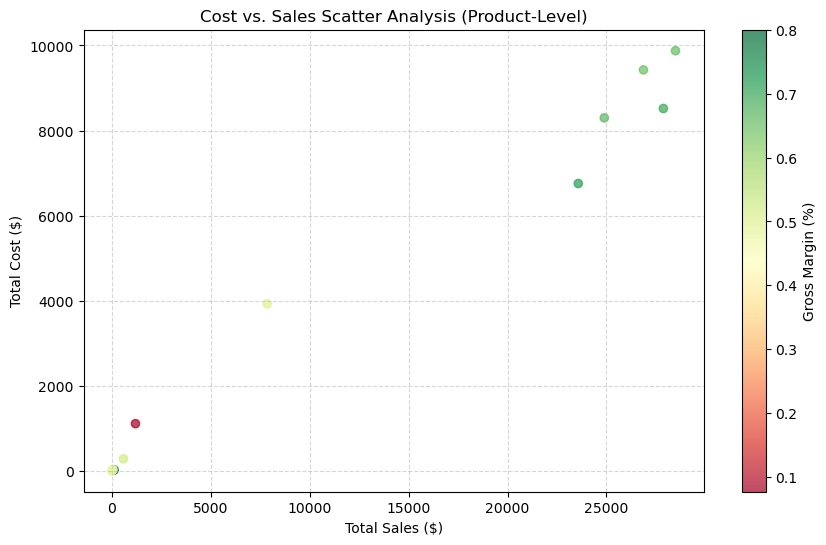

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(product_summary['Sales'], product_summary['Cost'], 
            c=product_summary['Gross_Margin'], cmap='RdYlGn', alpha=0.7)
plt.colorbar(label='Gross Margin (%)')
plt.title('Cost vs. Sales Scatter Analysis (Product-Level)')
plt.xlabel('Total Sales ($)')
plt.ylabel('Total Cost ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Key Performance Indicators (KPIs)

In [28]:
kpi = {
    'Average Gross Margin (%)': product_summary['Gross_Margin'].mean() * 100,
    'Average Profit per Unit': product_summary['Profit_per_Unit'].mean(),
    'Top 5 Products Profit Contribution (%)': (product_sorted_profit['Gross Profit'].head(5).sum() / product_sorted_profit['Gross Profit'].sum()) * 100
}

kpi

{'Average Gross Margin (%)': 57.38861352206299,
 'Average Profit per Unit': 2.6559999999999997,
 'Top 5 Products Profit Contribution (%)': 95.05774655725214}

## Business Recommendations

1. High-profit, high-margin products should be protected and prioritized.
2. High-sales but low-margin products require pricing or cost review.
3. Margin-risk products should be evaluated for repositioning or discontinuation.
4. Low-margin divisions require strategic cost or sourcing intervention.
5. Profit concentration suggests the need for portfolio diversification.

## Final Conclusion

This analysis reveals that a small subset of products contributes disproportionately to overall profitability,
highlighting a strong profit concentration risk. While several products demonstrate high margins and strong unit
economics, others generate high sales volumes but weaken overall margins due to cost inefficiencies.

Division-level analysis indicates structural margin differences, suggesting the need for targeted sourcing,
pricing, and portfolio optimization strategies. Overall, the insights support data-driven decision-making
for pricing, cost renegotiation, and product rationalization to improve long-term financial sustainability.